Professional Indoor Temperature Prediction System


Enter shutdown time indoor temperature (°C):  26
Enter next day 9 AM outdoor temperature (°C):  30.1


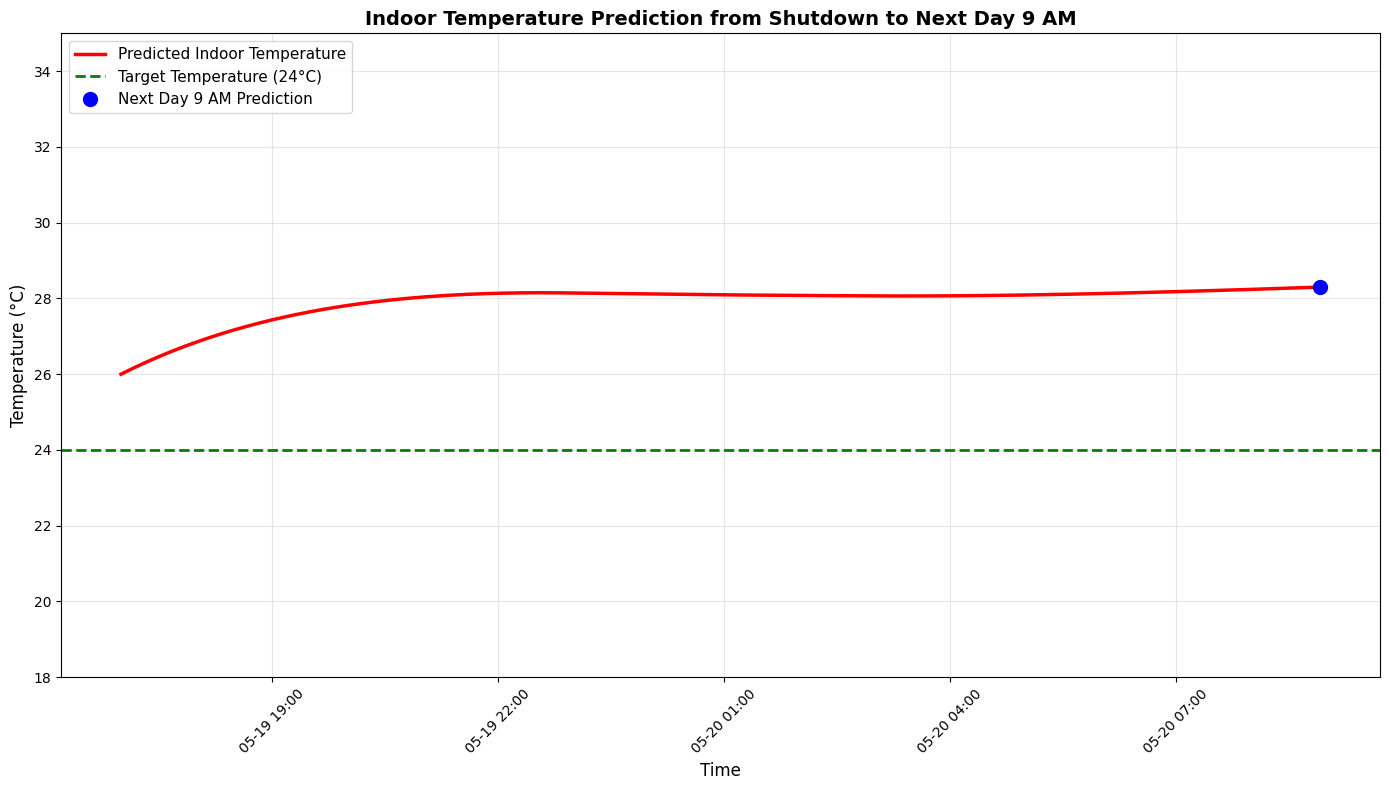


Prediction Results:
Shutdown indoor temperature: 26.0°C
Next day 9 AM outdoor temperature: 30.1°C
Predicted next day 9 AM indoor temperature: 28.30°C
The room will be 4.30°C warmer than target at 9 AM

You can query the temperature at any time point:


Enter time (HH:MM format, e.g., '22:00', or press Enter to exit):  08:47


Predicted temperature at 08:47: 28.29°C


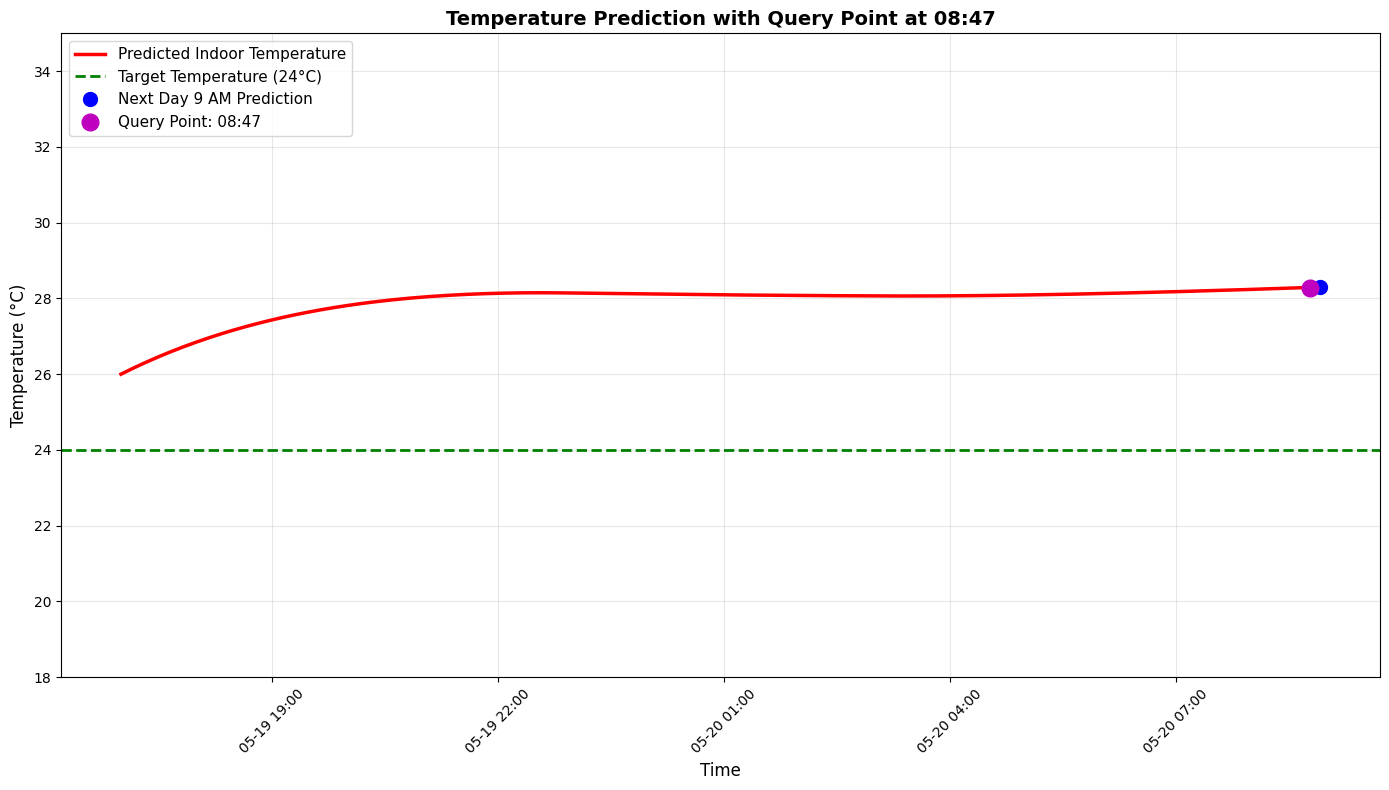

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import matplotlib.dates as mdates

class ProfessionalTemperaturePredictor:
    """
    Professional Indoor Temperature Prediction System
    With configurable y-axis range (18-35°C) and user inputs
    """
    
    def __init__(self):
        # Model parameters (calibrated for realistic dynamics)
        self.R_ie = 0.107   # Indoor-outdoor resistance
        self.R_im = 0.041   # Indoor-mass resistance
        self.C_i = 484500  # Indoor air capacitance
        self.C_m = 32800000  # Thermal mass capacitance
        
        # Initial state
        self.T_r = None    # Indoor temperature
        self.T_m = None    # Mass temperature
        
        # Prediction results
        self.times = []
        self.temperatures = []
        self.start_time = None
    
    def initialize(self, shutdown_temp):
        """Initialize temperature states"""
        self.T_r = shutdown_temp
        self.T_m = shutdown_temp + 2.0  # Mass temperature slightly higher
    
    def predict_step(self, T_out, dt=300):
        """Single prediction step"""
        # Calculate derivatives
        dT_r = ((T_out - self.T_r) / self.R_ie + (self.T_m - self.T_r) / self.R_im) / self.C_i
        dT_m = ((self.T_r - self.T_m) / self.R_im) / self.C_m
        
        # Update temperatures
        self.T_r += dT_r * dt
        self.T_m += dT_m * dt
        
        return self.T_r
    
    def predict(self, next_day_9am_outdoor, hours=16, dt=300):
        """
        Predict temperature for specified hours
        with realistic outdoor temperature variation
        """
        # Initialize results
        time_steps = int(hours * 3600 / dt)
        self.temperatures = [self.T_r]
        self.times = [self.start_time]
        
        # Simulate each time step
        for i in range(1, time_steps):
            current_time = self.start_time + timedelta(minutes=5*i)
            self.times.append(current_time)
            
            # Calculate outdoor temperature based on time
            T_out = self.calculate_outdoor_temp(current_time, next_day_9am_outdoor)
            
            # Predict next temperature
            T_next = self.predict_step(T_out, dt)
            self.temperatures.append(T_next)
        
        return np.array(self.temperatures)
    
    def calculate_outdoor_temp(self, current_time, next_day_9am_outdoor):
        """
        Calculate outdoor temperature based on time
        with realistic nighttime cooling and morning warming
        """
        # Calculate hours from shutdown
        hours_from_start = (current_time - self.start_time).total_seconds() / 3600
        
        # Temperature phases:
        if hours_from_start < 6:  # Evening cooling
            # Start at shutdown_temp + 3°C, cool to min_temp
            shutdown_temp = next_day_9am_outdoor + 5  # Assume shutdown is warmer
            min_temp = next_day_9am_outdoor - 2
            return shutdown_temp - (shutdown_temp - min_temp) * (hours_from_start / 6)
        elif hours_from_start < 10:  # Stable cool period
            return next_day_9am_outdoor - 2  # Stable temperature
        else:  # Morning warming
            # Warm from min_temp to next_day_9am_outdoor
            min_temp = next_day_9am_outdoor - 2
            warming_hours = hours_from_start - 10
            return min_temp + (next_day_9am_outdoor - min_temp) * (warming_hours / 6)
    
    def get_temperature_at_time(self, target_time_str):
        """Get temperature at specific time (HH:MM format)"""
        try:
            hour, minute = map(int, target_time_str.split(':'))
            target_time = self.start_time.replace(hour=hour, minute=minute)
            
            # Adjust for next day if needed
            if target_time < self.start_time:
                target_time += timedelta(days=1)
            
            # Find closest time point
            min_diff = float('inf')
            closest_temp = None
            
            for time, temp in zip(self.times, self.temperatures):
                time_diff = abs((time - target_time).total_seconds())
                if time_diff < min_diff:
                    min_diff = time_diff
                    closest_temp = temp
            
            return closest_temp
        except:
            return None

def get_user_input():
    """Get user input for prediction scenario"""
    print("Professional Indoor Temperature Prediction System")
    print("=" * 60)
    
    # Get shutdown time indoor temperature
    while True:
        try:
            shutdown_temp = float(input("Enter shutdown time indoor temperature (°C): "))
            break
        except ValueError:
            print("Please enter a valid number (e.g., 24.5).")
    
    # Get next day 9 AM outdoor temperature
    while True:
        try:
            next_day_9am_outdoor = float(input("Enter next day 9 AM outdoor temperature (°C): "))
            break
        except ValueError:
            print("Please enter a valid number (e.g., 28.5).")
    
    return shutdown_temp, next_day_9am_outdoor

def create_professional_plot(times, temperatures):
    """
    Create professional visualization with y-axis 18-35°C
    """
    plt.figure(figsize=(14, 8))
    
    # Plot predicted temperature
    plt.plot(times, temperatures, 'r-', linewidth=2.5, label='Predicted Indoor Temperature')
    
    # Plot target temperature
    plt.axhline(y=24, color='g', linestyle='--', linewidth=2, label='Target Temperature (24°C)')
    
    # Mark next day 9 AM prediction
    next_day_9am = times[-1]
    next_day_9am_temp = temperatures[-1]
    plt.plot(next_day_9am, next_day_9am_temp, 'bo', markersize=10, label='Next Day 9 AM Prediction')
    
    # Set y-axis range to 18-35°C as specified
    plt.ylim(18, 35)
    
    # Set labels and title
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Temperature (°C)', fontsize=12)
    plt.title('Indoor Temperature Prediction from Shutdown to Next Day 9 AM', fontsize=14, fontweight='bold')
    
    # Add legend
    plt.legend(fontsize=11, loc='upper left')
    
    # Format x-axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=3))
    plt.xticks(rotation=45)
    
    # Add grid
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return plt

def main():
    """Main function to run the prediction system"""
    # Get user inputs
    shutdown_temp, next_day_9am_outdoor = get_user_input()
    
    # Initialize model
    model = ProfessionalTemperaturePredictor()
    model.initialize(shutdown_temp)
    
    # Set start time (assume shutdown at 17:00)
    model.start_time = datetime.now().replace(hour=17, minute=0, second=0, microsecond=0)
    
    # Run prediction for 16 hours (to next day 9:00)
    temperatures = model.predict(next_day_9am_outdoor, hours=16)
    
    # Create professional visualization
    plt = create_professional_plot(model.times, temperatures)
    plt.show()
    
    # Display key results
    next_day_9am_temp = temperatures[-1]
    print(f"\nPrediction Results:")
    print(f"Shutdown indoor temperature: {shutdown_temp}°C")
    print(f"Next day 9 AM outdoor temperature: {next_day_9am_outdoor}°C")
    print(f"Predicted next day 9 AM indoor temperature: {next_day_9am_temp:.2f}°C")
    
    # Temperature difference analysis
    temp_diff = next_day_9am_temp - 24
    if temp_diff > 0:
        print(f"The room will be {temp_diff:.2f}°C warmer than target at 9 AM")
    else:
        print(f"The room will be {abs(temp_diff):.2f}°C cooler than target at 9 AM")
    
    # Temperature query functionality
    print("\nYou can query the temperature at any time point:")
    while True:
        time_input = input("Enter time (HH:MM format, e.g., '22:00', or press Enter to exit): ").strip()
        
        if time_input == "":
            break
        
        temp = model.get_temperature_at_time(time_input)
        if temp is not None:
            print(f"Predicted temperature at {time_input}: {temp:.2f}°C")
            
            # Create visualization with query point
            plt.figure(figsize=(14, 8))
            plt.plot(model.times, temperatures, 'r-', linewidth=2.5, label='Predicted Indoor Temperature')
            plt.axhline(y=24, color='g', linestyle='--', linewidth=2, label='Target Temperature (24°C)')
            plt.plot(model.times[-1], temperatures[-1], 'bo', markersize=10, label='Next Day 9 AM Prediction')
            
            # Find query time point
            hour, minute = map(int, time_input.split(':'))
            query_time = model.start_time.replace(hour=hour, minute=minute)
            if query_time < model.start_time:
                query_time += timedelta(days=1)
            
            # Add query point to plot
            plt.plot(query_time, temp, 'mo', markersize=12, label=f'Query Point: {time_input}')
            
            # Set y-axis range
            plt.ylim(18, 35)
            
            # Set labels and title
            plt.xlabel('Time', fontsize=12)
            plt.ylabel('Temperature (°C)', fontsize=12)
            plt.title(f'Temperature Prediction with Query Point at {time_input}', fontsize=14, fontweight='bold')
            
            # Add legend
            plt.legend(fontsize=11, loc='upper left')
            
            # Format x-axis
            plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
            plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=3))
            plt.xticks(rotation=45)
            
            # Add grid
            plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
        else:
            print("Invalid time format. Please use HH:MM format.")

if __name__ == "__main__":
    main()

In [1]:
import numpy as np
import pickle
from datetime import datetime, timedelta
import matplotlib.dates as mdates

class TemperatureModel:
    """室内温度预测模型（基于 RC 参数和目标温度）"""
    def __init__(self, target_temp, R_ie=0.107, R_im=0.041, C_i=484500, C_m=32800000):
        self.target_temp = target_temp
        self.R_ie = R_ie
        self.R_im = R_im
        self.C_i = C_i
        self.C_m = C_m

    def predict(self, shutdown_temp, next_day_9am_outdoor, shutdown_time_hour=17, hours=16, dt_sec=300):
        """
        模拟从关机到次日 9 AM 的室内温度变化
        shutdown_temp: 关机时室内温度（℃）
        next_day_9am_outdoor: 次日 9 AM 的室外温度（℃）
        shutdown_time_hour: 关机时刻（小时），默认 17:00
        hours: 模拟时长（小时），默认 16 小时（到次日 9:00）
        dt_sec: 时间步长（秒），默认 300 秒（5 分钟）
        返回: times (list of datetime), temperatures (list of float)
        """
        # 初始化状态
        T_r = shutdown_temp
        T_m = shutdown_temp + 2.0  # 初始墙体温度略高于室内
        start_time = datetime.now().replace(hour=shutdown_time_hour, minute=0, second=0, microsecond=0)
        times = [start_time]
        temps = [T_r]
        dt = dt_sec
        n_steps = int(hours * 3600 / dt)

        for i in range(1, n_steps):
            current_time = start_time + timedelta(seconds=i*dt)
            times.append(current_time)
            # 计算当前室外温度（使用与 ProfessionalTemperaturePredictor 相同的分段函数）
            hours_from_start = (current_time - start_time).total_seconds() / 3600
            T_out = self._outdoor_temp(hours_from_start, next_day_9am_outdoor)
            # RC 更新
            dT_r = ((T_out - T_r) / self.R_ie + (T_m - T_r) / self.R_im) / self.C_i
            dT_m = ((T_r - T_m) / self.R_im) / self.C_m
            T_r += dT_r * dt
            T_m += dT_m * dt
            temps.append(T_r)
        return times, temps

    def _outdoor_temp(self, hours_from_start, next_day_9am_outdoor):
        """分段室外温度模型（与原 ProfessionalTemperaturePredictor 一致）"""
        if hours_from_start < 6:  # 傍晚降温
            shutdown_temp = next_day_9am_outdoor + 5
            min_temp = next_day_9am_outdoor - 2
            return shutdown_temp - (shutdown_temp - min_temp) * (hours_from_start / 6)
        elif hours_from_start < 10:  # 夜间稳定
            return next_day_9am_outdoor - 2
        else:  # 清晨升温
            min_temp = next_day_9am_outdoor - 2
            warming_hours = hours_from_start - 10
            return min_temp + (next_day_9am_outdoor - min_temp) * (warming_hours / 6)

    def get_temperature_at_time(self, time_str, times, temperatures):
        """查询指定时间（HH:MM）的温度（需要在 predict 之后调用）"""
        try:
            hour, minute = map(int, time_str.split(':'))
            # 在 times 序列中找到最接近该时刻的温度
            target_minutes = hour * 60 + minute
            best_diff = float('inf')
            best_temp = None
            for t, temp in zip(times, temperatures):
                t_minutes = t.hour * 60 + t.minute
                # 如果目标时间在次日（小于起始时间），则加一天
                if target_minutes < times[0].hour * 60 + times[0].minute:
                    target_minutes += 24 * 60
                diff = abs(t_minutes - target_minutes)
                if diff < best_diff:
                    best_diff = diff
                    best_temp = temp
            return best_temp
        except:
            return None

# 生成三个模型文件
if __name__ == "__main__":
    for target in [24, 25, 26]:
        model = TemperatureModel(target_temp=target)
        with open(f'temperature_model_{target}.pkl', 'wb') as f:
            pickle.dump(model, f)
        print(f"模型文件已生成: temperature_model_{target}.pkl")

模型文件已生成: temperature_model_24.pkl
模型文件已生成: temperature_model_25.pkl
模型文件已生成: temperature_model_26.pkl
